# 🏗️ 构建你的投资组合

## 本节目标

把前面学会的所有技能串起来，从头到尾完成一件事：

**从几千只基金中，找出 3-5 只，搭一个属于你自己的投资组合。**

具体步骤：
1. 用筛选器海选基金
2. 检查它们是不是真的"不同"（相关性）
3. 用数学方法找到最优配比
4. 看看当前市场给什么信号
5. 生成你的投资计划书

---

### 先理解：为什么需要"组合"而不是"一只"

```
只买一只基金：
  赚了 → 开心
  亏了 → 全部身家一起亏

买三只相关性低的基金：
  基金A跌了 → 基金B可能涨了 → 组合整体没怎么跌
```

**分散不是买很多只，而是买"不同方向"的资产。**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

from scripts.data.client import get_fund_nav, get_fund_ranking, get_fund_list
from scripts.analysis.fund_scanner import scan_funds, calculate_metrics
from scripts.analysis.risk import risk_report, max_drawdown
from scripts.analysis.correlation import compute_correlation, plot_correlation_heatmap
from scripts.strategy.portfolio import (
    optimize_portfolio, efficient_frontier, portfolio_metrics,
    max_sharpe_optimize, min_variance_optimize, risk_parity_optimize,
    portfolio_returns,
)
from scripts.strategy.signals import composite_signal
from scripts.utils import viz

print("✅ 所有模块就绪 — 开始构建你的投资组合！")

✅ 所有模块就绪 — 开始构建你的投资组合！


## 第一步：海选基金

用筛选器从全市场筛出符合条件的基金。

**调整下面的参数来定制你的筛选条件**：
- `fund_type`: stock(股票) / bond(债券) / mix(混合) / index(指数)
- `min_return`: 最低年化收益，设 0 表示不限制
- `max_drawdown`: 最大可接受回撤，这是你能承受的最大亏损
- `min_sharpe`: 最低夏普比率，0.3 以上才算有性价比

In [2]:
# 👇 修改这些参数来定制筛选
result = scan_funds(
    fund_type="index",      # 指数基金对新手续费低，适合新手
    min_return=0,            # 不限制收益
    max_drawdown=30,         # 最大回撤不超过 30%（你能接受10万变7万吗？）
    min_sharpe=0.3,          # 夏普比率至少 0.3
    top_n=20,                # 返回前 20 名
)

if not result.empty:
    print(f"✅ 找到 {len(result)} 只符合条件的基金：")
    display(result[["code", "name", "annual_return", "max_drawdown", "sharpe_ratio"]])
else:
    print("😕 没有符合条件的，试试放宽条件（提高 max_drawdown 或降低 min_return）")

[SCAN] 正在扫描基金 (类型=index, 收益>=0%, 回撤<=30%, 夏普>=0.3)...
  [30/30] 分析 014111 嘉实中证稀有金属主题ETF发起联接C....
  完成，成功分析 30 只基金
✅ 找到 20 只符合条件的基金：


,code,name,annual_return,max_drawdown,sharpe_ratio
0,008326,东财通信A,245.68,-16.24,5.95
1,008327,东财通信C,244.83,-16.26,5.93
2,020899,天弘中证全指通信设备指数发起A,223.00,-17.12,5.49
3,020900,天弘中证全指通信设备指数发起C,222.35,-17.13,5.48
4,020691,博时中证全指通信设备指数发起式A,217.30,-17.18,5.41
5,020692,博时中证全指通信设备指数发起式C,216.68,-17.19,5.39
6,022500,国泰中证全指通信设备ETF联接E,211.34,-17.12,5.33
7,007817,国泰中证全指通信设备ETF联接A,211.38,-17.10,5.32
8,007818,国泰中证全指通信设备ETF联接C,210.43,-17.12,5.30
9,021933,富国中证通信设备主题ETF发起式联接A,190.65,-14.91,4.77


## 第二步：挑选候选基金

从筛选结果中选出 3-5 只你感兴趣的。**建议选不同类型/不同方向的**，比如
- 一只大盘（沪深300相关）
- 一只中小盘（中证500相关）
- 一只债券基金（稳定器）

这样它们才不会同涨同跌。

In [3]:
# 👇 从上面的筛选结果中挑几只，填到这里
MY_CODES = ["110020", "001632", "050027"]

print("📋 我的候选基金：")
for code in MY_CODES:
    try:
        nav = get_fund_nav(code)
        m = calculate_metrics(nav)
        print(f"  {code}: 年化 {m['annual_return']}%, "
              f"回撤 {m['max_drawdown']}%, "
              f"夏普 {m['sharpe_ratio']}, "
              f"数据 {m['data_days']} 天")
    except Exception as e:
        print(f"  {code}: ❌ {e}")

print(f"\n💡 确认这 {len(MY_CODES)} 只基金，准备进入下一步...")

📋 我的候选基金：
  110020: 年化 29.89%, 回撤 -7.24%, 夏普 2.05, 数据 365 天
  001632: 年化 -9.3%, 回撤 -17.06%, 夏普 -0.77, 数据 365 天
  050027: 年化 -0.78%, 回撤 -2.35%, 夏普 -1.74, 数据 365 天

💡 确认这 3 只基金，准备进入下一步...


## 第三步：检查相关性 — 它们真的不一样吗？

如果两只基金的相关性 > 0.85，说明它们基本同涨同跌，买两只等于买一只。

**我们要的是相关性 < 0.7 的组合**，这样才能真正分散风险。

📊 相关性矩阵（越接近 1 = 越同步）：


,110020,001632,050027
110020,1.00,0.48,-0.11
001632,0.48,1.00,-0.03
050027,-0.11,-0.03,1.00


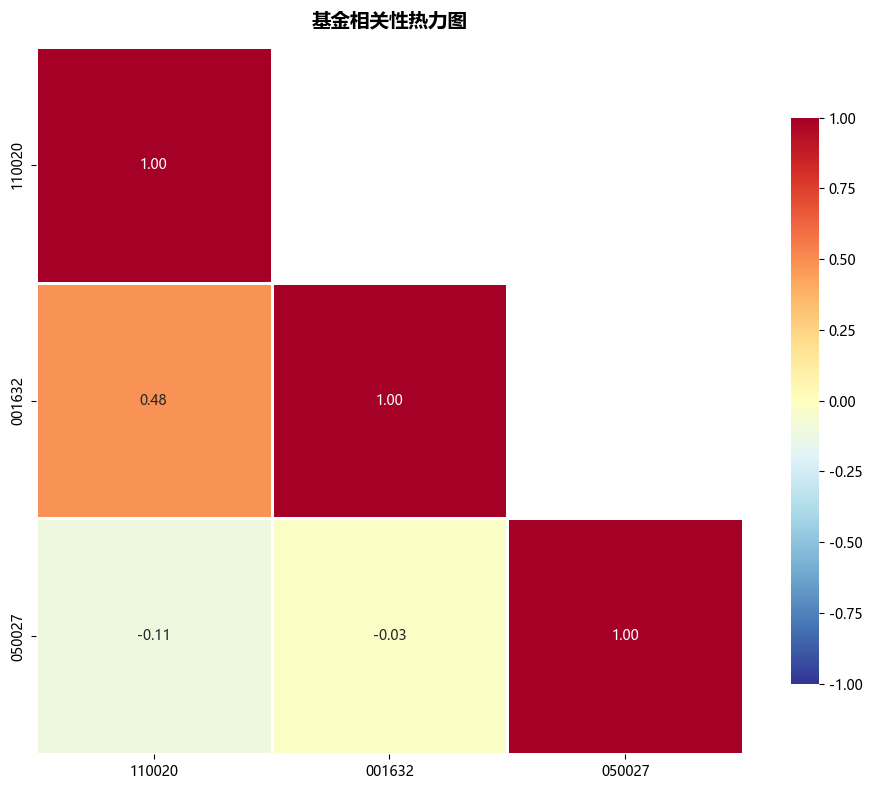


📊 解读：
  110020 vs 001632: r=0.48 ✅ 适中
  110020 vs 050027: r=-0.11 ✅ 适中
  001632 vs 050027: r=-0.03 ✅ 适中

✅ 组合内部相关性适中，分散效果不错！


In [5]:
# 计算相关性矩阵
corr = compute_correlation(MY_CODES)

if not corr.empty:
    print("📊 相关性矩阵（越接近 1 = 越同步）：")
    display(corr.round(2))

    # 画热力图
    fig = plot_correlation_heatmap(corr)
    plt.show()

    # 解读
    print("\n📊 解读：")
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            val = corr.iloc[i, j]
            level = ("⚠️ 极高" if val > 0.85 else
                    ("偏高" if val > 0.7 else "✅ 适中"))
            print(f"  {corr.columns[i]} vs {corr.columns[j]}: r={val:.2f} {level}")
            if val > 0.85:
                high_corr.append((corr.columns[i], corr.columns[j]))

    if high_corr:
        print(f"\n⚠️ 发现高度相关的配对，考虑替换其中一只！")
    else:
        print(f"\n✅ 组合内部相关性适中，分散效果不错！")
else:
    print("数据不足，请确保至少 2 只基金有足够的历史数据")

## 第四步：准备数据 — 构建收益矩阵

把多只基金的日收益率对齐，这是组合优化的原材料。

In [7]:
returns_df, mean_returns, cov_matrix = portfolio_returns(MY_CODES)

print(f"📊 收益矩阵: {returns_df.shape[0]} 个交易日, {returns_df.shape[1]} 只基金")
print(f"\n年化收益和风险：")
for i, code in enumerate(returns_df.columns):
    ann_ret = mean_returns[i] * 100
    ann_vol = np.sqrt(cov_matrix[i, i]) * 100
    print(f"  {code}: 年化收益 {ann_ret:.1f}%, 年化波动 {ann_vol:.1f}%")

print(f"\n💡 如果某只基金的年化收益是负数，说明这段时间它在亏钱。")
print(f"   短期表现差不一定代表以后差，但要心里有数。")

📊 收益矩阵: 243 个交易日, 3 只基金

年化收益和风险：
  110020: 年化收益 29.0%, 年化波动 13.6%
  001632: 年化收益 -8.7%, 年化波动 14.6%
  050027: 年化收益 -0.8%, 年化波动 1.6%

💡 如果某只基金的年化收益是负数，说明这段时间它在亏钱。
   短期表现差不一定代表以后差，但要心里有数。


## 第五步：等权重组合 — 先来个最简单的

每个人分一样的钱，不偏不倚。这是所有高级策略的对比基准。

In [8]:
# 等权重
n = len(MY_CODES)
equal_weights = np.array([1/n] * n)
eq_ret, eq_vol, eq_sharpe = portfolio_metrics(equal_weights, mean_returns, cov_matrix)

print("📊 等权重组合：")
for code, w in zip(MY_CODES, equal_weights):
    print(f"  {code}: {w*100:.0f}%")
print(f"  预期年化收益: {eq_ret*100:.1f}%")
print(f"  预期年化波动: {eq_vol*100:.1f}%")
print(f"  夏普比率: {eq_sharpe:.2f}")

print(f"\n💡 如果你不想折腾，等权重已经是一个不错的起点。")
print(f"   下面的优化方法试图在此基础上做得更好。")

📊 等权重组合：
  110020: 33%
  001632: 33%
  050027: 33%
  预期年化收益: 6.5%
  预期年化波动: 8.1%
  夏普比率: 0.56

💡 如果你不想折腾，等权重已经是一个不错的起点。
   下面的优化方法试图在此基础上做得更好。


## 第六步：三种优化策略对比

计算机来帮你找"最好"的配比。三种思路：

| 策略 | 目标 | 适合谁 |
|------|------|--------|
| 最大夏普 | 每单位风险换最多收益 | 追求性价比 |
| 最小方差 | 波动最小，稳如泰山 | 厌恶波动 |
| 风险平价 | 每个资产贡献相同的风险 | 不相信任何一只会一直好 |

**注意**：优化结果完全依赖历史数据。历史不代表未来，但对新手来说，这已经比乱配好得多。

In [9]:
# 三种优化
w_ms, ret_ms, vol_ms, sharpe_ms = max_sharpe_optimize(mean_returns, cov_matrix)
w_mv, ret_mv, vol_mv, sharpe_mv = min_variance_optimize(cov_matrix)
w_rp, ret_rp, vol_rp, rp_sharpe = risk_parity_optimize(cov_matrix)

print(f"{'策略':<10} {'收益':>8} {'波动':>8} {'夏普':>6}  |  ", end="")
for code in MY_CODES:
    print(f"{code:>8}", end=" ")
print()
print("-" * (50 + 10 * len(MY_CODES)))

for name, ret, vol, sharpe, weights in [
    ("等权重", eq_ret, eq_vol, eq_sharpe, equal_weights),
    ("最大夏普", ret_ms, vol_ms, sharpe_ms, w_ms),
    ("最小方差", ret_mv, vol_mv, sharpe_mv, w_mv),
    ("风险平价", ret_rp, vol_rp, rp_sharpe, w_rp),
]:
    print(f"{name:<10} {ret*100:>7.1f}% {vol*100:>7.1f}% {sharpe:>6.2f}  |  ", end="")
    for w in weights:
        print(f"{w*100:>7.1f}%", end=" ")
    print()

print(f"\n💡 建议：新手从「最小方差」或「风险平价」开始。")
print(f"   先把波动控制住，赚多少是市场给的。")
print(f"   等你有经验了，再逐步增加「最大夏普」的比例。")

策略               收益       波动     夏普  |    110020   001632   050027 
--------------------------------------------------------------------------------
等权重            6.5%     8.1%   0.56  |     33.3%    33.3%    33.3% 
最大夏普          13.7%     7.1%   1.65  |     50.0%     5.0%    45.0% 
最小方差           0.0%     6.0%  -0.33  |     28.9%    21.1%    50.0% 
风险平价           0.0%     2.2%  -0.91  |      8.2%     7.2%    84.6% 

💡 建议：新手从「最小方差」或「风险平价」开始。
   先把波动控制住，赚多少是市场给的。
   等你有经验了，再逐步增加「最大夏普」的比例。


## 第七步：有效前沿 — 最优解的"天花板"

有效前沿上的每一个点，都是在给定收益下风险最小的组合。

你的任何组合，理论上都不应该低于这条线。

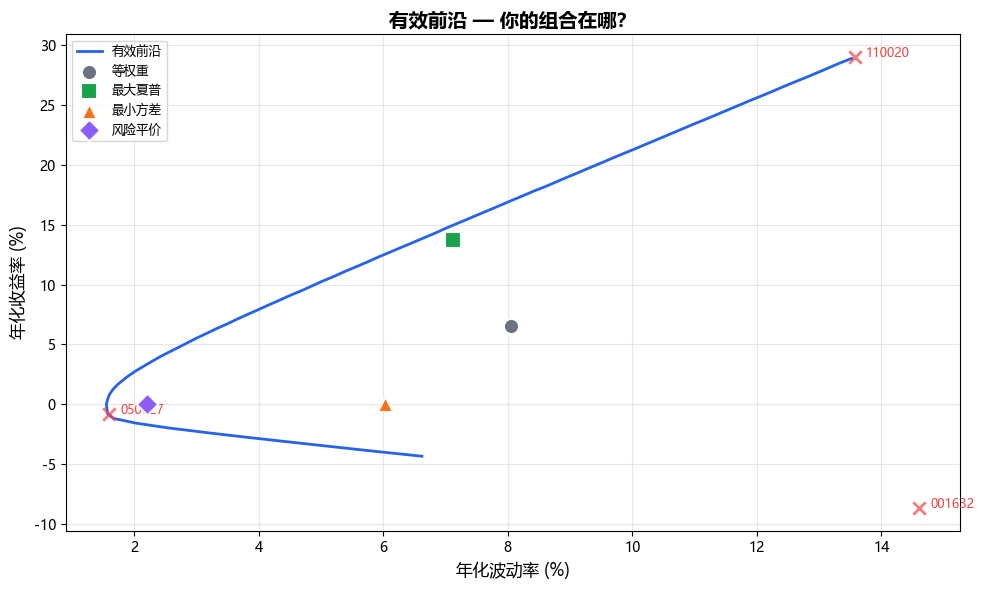


📊 看图指南：
  红色 X = 单只基金的位置
  蓝色线 = 最优组合能到达的位置（有效前沿）
  越靠左上 = 越好（高收益、低风险）

💡 如果你的策略点在红色 X 的左上方，说明组合确实改善了！


In [10]:
# 计算有效前沿
frontier = efficient_frontier(mean_returns, cov_matrix, points=100)

# 画图
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(frontier["volatility"], frontier["return"],
        color="#2563EB", linewidth=2, label="有效前沿")

# 标出四个策略
strategies = [
    (eq_vol*100, eq_ret*100, "等权重", "#6B7280", "o"),
    (vol_ms*100, ret_ms*100, "最大夏普", "#16A34A", "s"),
    (vol_mv*100, ret_mv*100, "最小方差", "#F97316", "^"),
    (vol_rp*100, ret_rp*100, "风险平价", "#8B5CF6", "D"),
]
for vol, ret, name, color, marker in strategies:
    ax.scatter(vol, ret, c=color, s=120, marker=marker,
               edgecolors="white", linewidth=1.5, zorder=5, label=name)

# 标出单只基金的位置
for i, code in enumerate(MY_CODES):
    vol_i = np.sqrt(cov_matrix[i, i]) * 100
    ret_i = mean_returns[i] * 100
    ax.scatter(vol_i, ret_i, c="#EF4444", s=80, marker="x",
               linewidth=2, zorder=4, alpha=0.7)
    ax.annotate(code, (vol_i, ret_i),
                textcoords="offset points", xytext=(8, 0),
                fontsize=9, color="#EF4444")

ax.set_xlabel("年化波动率 (%)", fontsize=12)
ax.set_ylabel("年化收益率 (%)", fontsize=12)
ax.set_title("有效前沿 — 你的组合在哪？", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print("\n📊 看图指南：")
print("  红色 X = 单只基金的位置")
print("  蓝色线 = 最优组合能到达的位置（有效前沿）")
print("  越靠左上 = 越好（高收益、低风险）")
print("\n💡 如果你的策略点在红色 X 的左上方，说明组合确实改善了！")

## 第八步：回撤对比 — 看看各策略最坏情况

收益只告诉你"可能赚多少"，回撤告诉你"最惨会多惨"。

**你要确保最惨的情况你也能扛住。**

In [ ]:
# 用等权重模拟历史表现
if not returns_df.empty:
    # 等权重组合的每日收益
    eq_daily = returns_df.dot(equal_weights)
    eq_nav = (1 + eq_daily).cumprod()

    # 最大夏普组合
    ms_daily = returns_df.dot(w_ms)
    ms_nav = (1 + ms_daily).cumprod()

    # 最小方差组合
    mv_daily = returns_df.dot(w_mv)
    mv_nav = (1 + mv_daily).cumprod()

    # 归一化比较
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(eq_nav.index, eq_nav, color="#6B7280", linewidth=1.5, label="等权重")
    ax1.plot(ms_nav.index, ms_nav, color="#16A34A", linewidth=1.5, label="最大夏普")
    ax1.plot(mv_nav.index, mv_nav, color="#F97316", linewidth=1.5, label="最小方差")
    ax1.set_title("各策略累计收益走势", fontsize=13, fontweight="bold")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 回撤曲线
    def drawdown(nav_series):
        return (nav_series / nav_series.cummax() - 1) * 100

    ax2.plot(eq_nav.index, drawdown(eq_nav), color="#6B7280", linewidth=1, label="等权重")
    ax2.plot(ms_nav.index, drawdown(ms_nav), color="#16A34A", linewidth=1, label="最大夏普")
    ax2.plot(mv_nav.index, drawdown(mv_nav), color="#F97316", linewidth=1, label="最小方差")
    ax2.fill_between(eq_nav.index, 0, -100, alpha=0.03, color="red")
    ax2.set_title("各策略回撤对比", fontsize=13, fontweight="bold")
    ax2.set_ylabel("回撤 (%)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

    dd_eq = drawdown(eq_nav).min()
    dd_ms = drawdown(ms_nav).min()
    dd_mv = drawdown(mv_nav).min()
    print(f"\n📊 最大回撤对比：")
    print(f"  等权重:   {dd_eq:.1f}%  (10万最多亏 {abs(dd_eq)*1000:.0f} 元)")
    print(f"  最大夏普: {dd_ms:.1f}%  (10万最多亏 {abs(dd_ms)*1000:.0f} 元)")
    print(f"  最小方差: {dd_mv:.1f}%  (10万最多亏 {abs(dd_mv)*1000:.0f} 元)")
    print(f"\n💡 你能接受哪个级别的亏损？选你能睡得着觉的策略。")
else:
    print("数据不足")

## 第九步：当前市场给什么信号？

用 PE 估值 + 均线 + RSI 综合判断：现在适合多买还是少买？

信号仅供参考——**定投纪律比择时重要得多。**

In [ ]:
# 对组合中每只基金分别看信号
for code in MY_CODES:
    try:
        signal = composite_signal(fund_code=code, index_code="000300")
        tag = {"BUY": "[BUY]", "SELL": "[SELL]", "HOLD": "[HOLD]", "WAIT": "[WAIT]"}.get(
            signal["overall_signal"], "[?]"
        )
        print(f"\n{tag} {code}: {signal['suggestion']}")
        for name, s in signal["signals"].items():
            sig = s.get("signal", "N/A")
            print(f"    [{name}]: {sig}")
            if "current_pe" in s:
                print(f"      当前PE: {s['current_pe']}, 分位: {s.get('percentile', '?')}%")
            if "detail" in s:
                print(f"      {s['detail']}")
            if "action" in s:
                print(f"      {s['action']}")
    except Exception as e:
        print(f"\n{code}: 信号获取失败 ({e})")

print(f"\n\n⚠️ 再次提醒：不要因为信号是 BUY 就盲目加仓，也不是 SELL 就恐慌清仓。")
print(f"   信号只是参考，定投纪律才是你的护身符。")

## 第十步：生成你的投资计划书

把前面的分析和选择，变成一份你可以执行的计划。

**填写下面的模板**，这就是你的投资"使用说明书"。

In [ ]:
# 👇 下面是你自己的投资计划 —— 认真填写！

MY_PLAN = {
    "目标": "30年后退休补充养老金，目标 200 万",  # ← 改成你的真实目标
    "每月投入": 3000,  # ← 改成你每月能投的金额
    "投资期限": 30,    # ← 改成你计划投多少年

    "组合方案": {
        "110020": {"名称": "沪深300联接", "比例": 40, "理由": "A股大盘核心资产"},
        "001632": {"名称": "中证500",     "比例": 30, "理由": "中盘成长"},
        "050027": {"名称": "纯债基金",     "比例": 30, "理由": "稳定器，降波动"},
    },

    "定投频率": "每月15号发工资后",
    "止盈规则": "PE分位 > 85% 时赎回盈利部分的50%",
    "再平衡": "每年12月最后一个周末调整一次，恢复目标比例",
    "紧急规则": "除非以下情况，否则不卖：1.急用救命钱 2.目标达成 3.买入的理由不成立了",

    "不做什么": [
        "不因为大跌而停止定投",
        "不追排行榜前10的热门基金",
        "不频繁换基金（至少持有1年再评估）",
        "不用下个月要用的钱来投",
        "不看每日涨跌，每月看一次就行",
    ],
}

# 计算预期
monthly = MY_PLAN["每月投入"]
years = MY_PLAN["投资期限"]
rate = 0.08  # 假设年化 8%

total_invested = monthly * 12 * years
# 复利终值公式
fv = monthly * ((1 + rate/12)**(12*years) - 1) / (rate/12)

print("=" * 60)
print("  📋 我的投资计划书")
print("=" * 60)
print(f"\n🎯 目标: {MY_PLAN['目标']}")
print(f"💰 每月投入: {monthly:,} 元")
print(f"⏱️  投资期限: {years} 年")
print(f"📈 预期年化: {rate*100:.0f}%")
print(f"\n📊 预期结果:")
print(f"  总投入:     {total_invested:>12,.0f} 元")
print(f"  预期最终:   {fv:>12,.0f} 元")
print(f"  预期收益:   {fv - total_invested:>12,.0f} 元")
print(f"  收益倍数:   {(fv/total_invested - 1)*100:.0f}%")

print(f"\n📊 组合配置:")
total_pct = 0
for code, info in MY_PLAN["组合方案"].items():
    pct = info["比例"]
    total_pct += pct
    allocated = monthly * pct / 100
    print(f"  {info['名称']} ({code}): {pct}% = 每月 {allocated:.0f} 元")
    print(f"    → {info['理由']}")

print(f"\n⚙️  执行规则:")
print(f"  定投频率: {MY_PLAN['定投频率']}")
print(f"  止盈规则: {MY_PLAN['止盈规则']}")
print(f"  再平衡:   {MY_PLAN['再平衡']}")
print(f"  紧急规则: {MY_PLAN['紧急规则']}")

print(f"\n🚫 纪律（我承诺不做的）:")
for rule in MY_PLAN["不做什么"]:
    print(f"  ❌ {rule}")

print(f"\n\n📅 下次复盘日期: ________（建议每季度一次）")
print(f"   问自己三个问题：")
print(f"   1. 比例还符合目标吗？")
print(f"   2. 买这些基金的理由还在吗？")
print(f"   3. 我的生活需要用这笔钱吗？")
print(f"\n如果三个答案都是 Yes → 什么都不用做，继续定投。")

## 📝 本节小结

恭喜！你已经完成了从"完全不懂"到"能构建投资组合"的完整旅程。

### 你学会的技能

| 技能 | 对应本节 | 掌握程度自评 |
|------|---------|------------|
| 用指标筛选基金 | 第一步 | □ 会 / □ 还行 / □ 需要复习 |
| 检查资产相关性 | 第三步 | □ 会 / □ 还行 / □ 需要复习 |
| 组合优化（三种策略） | 第六步 | □ 会 / □ 还行 / □ 需要复习 |
| 看懂有效前沿图 | 第七步 | □ 会 / □ 还行 / □ 需要复习 |
| 评估各策略回撤 | 第八步 | □ 会 / □ 还行 / □ 需要复习 |
| 看市场择时信号 | 第九步 | □ 会 / □ 还行 / □ 需要复习 |
| 写自己的投资计划 | 第十步 | □ 会 / □ 还行 / □ 需要复习 |

### 新手的终极建议

记住这五条黄金法则：

1. **宽基指数 + 定投 = 最小白也能赚钱的组合**
2. **跌了加仓不割肉，涨了别急着卖**
3. **投资之外，好好工作增加收入才是大头**
4. **少看账户，多读知识库**
5. **用闲钱，不要加杠杆，不要借钱投资**

### 后续你可以做的事

- 🔄 每季度回头运行一遍这个 notebook，调整计划
- 📖 重读 `knowledge/` 下你还没消化的内容
- 📊 用 `scripts/` 下的工具持续跟踪你的基金
- 🧪 当你有新想法时，修改本 notebook 的参数来测试

---

### 学习路线回顾

你已经走完了完整的学习路线：

```
✅ 第0步: notebooks/00-白话入门.ipynb      — 用白话理解基金
✅ 第1周: knowledge/01-基金基础/            — 基金是什么
✅ 第2周: knowledge/02-投资入门/            — 复利、定投
✅ 第3周: knowledge/04-分析方法/            — 看懂指标和技术分析
✅ 第4周: knowledge/05-投资策略/ + 06-风险管理/ + 本 notebook
```

---

> ⚠️ 免责声明：本项目所有内容仅供学习参考，不构成投资建议。
> 投资有风险，入市需谨慎。过去的表现不代表未来的收益。